# 4 · Scientific control & offline safety

Two more advantages of `chc` on realistic control problems:

1. **Constrained optimal control on nonlinear scientific dynamics** — flatten an epidemic curve under a
   hospital-capacity constraint with minimal intervention (the Bazykin / Riznichenko / Marchuk-immunology
   lineage of nonlinear population models + optimal control).
2. **Offline safety via pessimism** — a controller trained offline must not exploit its model where it
   was never trained; the pessimism/support layer keeps actions inside the region the data justifies.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc.benchmark import SupportShiftTask
from chc.epidemic import SIRDynamics, optimal_npi
from chc.integrate import rollout

## Flatten the curve: SIR + NPI under a capacity constraint

A fast epidemic ($R_0=6$) overshoots hospital capacity. `optimal_npi` finds the *least* intervention
(a non-pharmaceutical-intervention schedule reducing transmission) that keeps infections under the cap
— projected-gradient optimal control differentiating through the rollout.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


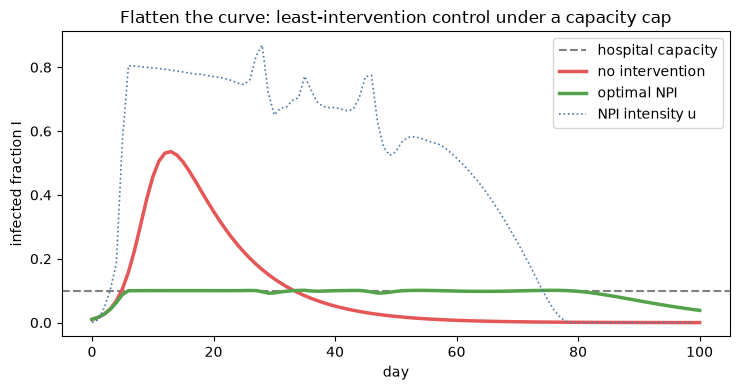

uncontrolled peak I = 0.536   (cap 0.1)
controlled   peak I = 0.101   flattened to the cap
total NPI effort    = 44.1


In [2]:
model = SIRDynamics(beta=0.6, gamma=0.1)  # R0 = 6
x0 = jnp.array([0.99, 0.01])
dt, horizon, i_max = 1.0, 100, 0.1

xs_free = rollout(model, x0, jnp.zeros((horizon, 1)), dt)
us = optimal_npi(model, x0, dt, horizon, i_max, steps=400)
xs_ctrl = rollout(model, x0, us, dt)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.axhline(i_max, ls="--", c="0.5", label="hospital capacity")
ax.plot(xs_free[:, 1], lw=2.5, color="#E45756", label="no intervention")
ax.plot(xs_ctrl[:, 1], lw=2.5, color="#54A24B", label="optimal NPI")
ax.plot(us[:, 0], lw=1.2, ls=":", color="#4C78A8", label="NPI intensity u")
ax.set_xlabel("day")
ax.set_ylabel("infected fraction I")
ax.set_title("Flatten the curve: least-intervention control under a capacity cap")
ax.legend()
plt.tight_layout()
plt.show()

print(f"uncontrolled peak I = {float(jnp.max(xs_free[:, 1])):.3f}   (cap {i_max})")
print(f"controlled   peak I = {float(jnp.max(xs_ctrl[:, 1])):.3f}   flattened to the cap")
print(f"total NPI effort    = {float(jnp.sum(us)):.1f}")

## Offline safety: pessimism vs a greedy controller

Here a **linear model** matches a plant whose control effectiveness *collapses off-support* (a real
actuator has a sweet spot). The greedy controller extrapolates to large actions to chase the model's
promised gains — and stalls on the true plant. The pessimistic controller keeps actions inside the
offline support and stays safe. The oracle plans on the true plant.

In [3]:
results = SupportShiftTask().run()
board = pd.DataFrame(
    [
        {
            "controller": r.controller,
            "true cost": r.cost,
            "regret vs oracle": r.regret,
            "out-of-support rate": r.ood_rate,
        }
        for r in sorted(results, key=lambda r: r.regret)
    ]
).set_index("controller")
board.round(2)

,true cost,regret vs oracle,out-of-support rate
controller,,,
oracle,20.65,0.00,0.00
pessimistic,22.88,2.23,0.00
greedy,26.20,5.56,0.56


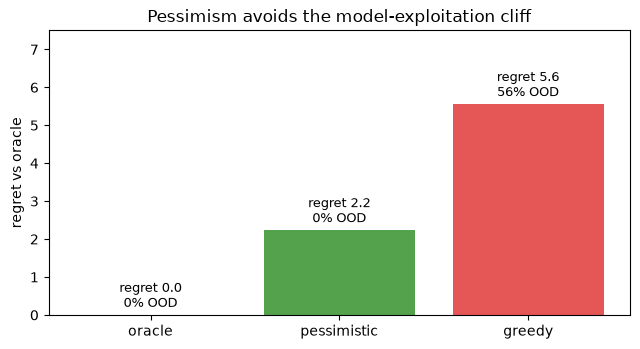

In [4]:
by = {r.controller: r for r in results}
fig, ax = plt.subplots(figsize=(6.5, 3.6))
names = ["oracle", "pessimistic", "greedy"]
regrets = [by[n].regret for n in names]
oods = [by[n].ood_rate for n in names]
xpos = range(len(names))
ax.bar(xpos, regrets, color=["#4C78A8", "#54A24B", "#E45756"])
ax.set_xticks(list(xpos))
ax.set_xticklabels(names)
ax.set_ylabel("regret vs oracle")
ax.set_title("Pessimism avoids the model-exploitation cliff")
for i, (rg, od) in enumerate(zip(regrets, oods, strict=True)):
    ax.text(i, rg + 0.1, f"regret {rg:.1f}\n{od:.0%} OOD", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(regrets) * 1.35)
plt.tight_layout()
plt.show()

**The greedy controller** pushes a large fraction of its actions out of the logged support and pays for
it in regret; **pessimism** keeps every action in-support and roughly halves the regret. Here the
safeguard is *pessimism*, not causality — the two failure modes (confounding and off-support model
error) are orthogonal, and `chc` addresses both.

### Takeaway
`chc` does constrained optimal control on genuine nonlinear dynamics, and its offline-safety layer stops
an offline-trained controller from exploiting model error where the data cannot back it up.